In [ ]:
pip install joblib

In [ ]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib as plt  # type: ignore
import seaborn as sns # type: ignore
import xgboost as xgb # type: ignore
from xgboost import XGBRegressor # type: ignore
from sklearn.model_selection import train_test_split, GridSearchCV # type: ignore
from sklearn.metrics import mean_squared_error, r2_score # type: ignore
import os
import joblib # type: ignore


In [61]:
dr = pd.read_excel('descriptors.xlsx')
del dr['ID']
dr.head()


,smiles,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [62]:
df = pd.read_csv("Morgan.csv")
del df['ID']
df.head()

,smiles,morgan_fingerprint
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...


In [63]:
def split_bits(row):
    if pd.isna(row['morgan_fingerprint']):
        return pd.Series([np.nan] * 1024)  
    else:
        return pd.Series(list(row['morgan_fingerprint']))

bit_columns = df.apply(split_bits, axis=1)

bit_columns.columns = [f'F_{i+1}' for i in range(bit_columns.shape[1])]
final_df = pd.concat([df.reset_index(drop=True), bit_columns], axis=1)
final_df.head()

,smiles,morgan_fingerprint,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [64]:
final_df = final_df.dropna()

y1 = dr[dr['smiles'].isin(final_df['smiles'])]

In [65]:
input = final_df.copy()
del input['morgan_fingerprint']
del input['smiles']
input.head()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [66]:
del y1['smiles']

In [67]:
y1.head()

,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,nbo_P_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,0.801914,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,0.816302,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,0.796412,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,0.798225,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,0.787516,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [68]:
y1.head()

,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,nbo_P_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,0.801914,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,0.816302,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,0.796412,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,0.798225,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,0.787516,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [73]:
for column in input.columns:
    if input[column].dtype == 'object':
        input[column] = pd.to_numeric(input[column], errors='coerce')

# Check the new data types
print(input.dtypes)

F_1       int64
F_2       int64
F_3       int64
F_4       int64
F_5       int64
          ...  
F_1020    int64
F_1021    int64
F_1022    int64
F_1023    int64
F_1024    int64
Length: 1024, dtype: object


In [ ]:
import os
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Assuming X and y1 are already defined
X = input  
Y = y1.copy()  

models = {}
results_list = []

# Create directory to save models
os.makedirs('models_decision_tree', exist_ok=True)

for feature in Y.columns:
    y = Y[feature]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and fit Decision Tree model
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred) if len(set(y_test)) > 1 else 0
    rmse = mean_squared_error(y_test, y_pred, squared=False)

    # Store results
    results_list.append({'Feature': feature, 'R²': r2, 'RMSE': rmse})
    models[feature] = model
    joblib.dump(model, f'models_decision_tree/model_{feature}.joblib')

# Save results to CSV
results_df = pd.DataFrame(results_list)
results_df.to_csv('model_performance_decision_tree.csv', index=False)


LASSO + LINEAR VISUALIZATION

VISUALIZATION

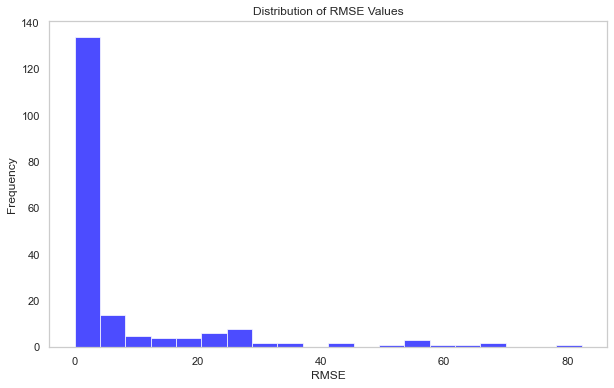

In [104]:
plt.figure(figsize=(10, 6))
plt.hist(data['RMSE'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of RMSE Values')
plt.xlabel('RMSE')
plt.ylabel('Frequency')
plt.grid()
plt.show()


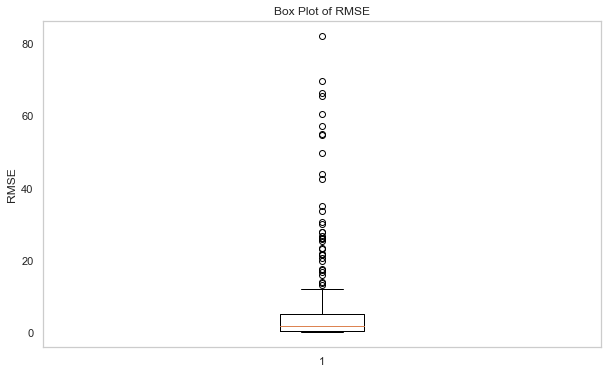

In [105]:
plt.figure(figsize=(10, 6))
plt.boxplot(data['RMSE'])
plt.title('Box Plot of RMSE')
plt.ylabel('RMSE')
plt.grid()
plt.show()


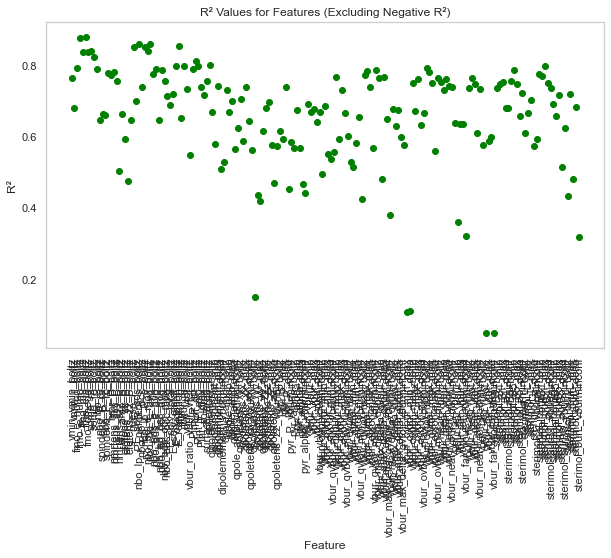

In [112]:
# Filter out rows with negative R²
filtered_data_r2 = data[data['R²'] >= 0]

# Scatter plot for R²
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data_r2['Feature'], filtered_data_r2['R²'], color='green')
plt.title('R² Values for Features (Excluding Negative R²)')
plt.xlabel('Feature')
plt.ylabel('R²')
plt.xticks(rotation=90)
plt.grid()
plt.show()


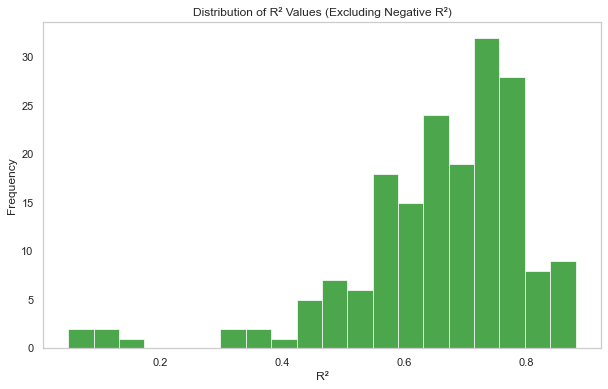

In [113]:
plt.figure(figsize=(10, 6))
plt.hist(filtered_data_r2['R²'], bins=20, color='green', alpha=0.7)
plt.title('Distribution of R² Values (Excluding Negative R²)')
plt.xlabel('R²')
plt.ylabel('Frequency')
plt.grid()
plt.show()


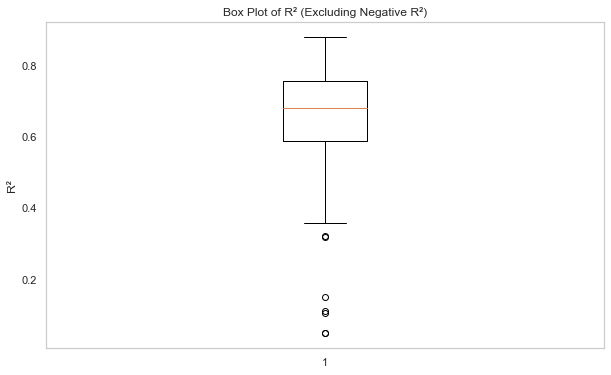

In [114]:
plt.figure(figsize=(10, 6))
plt.boxplot(filtered_data_r2['R²'])
plt.title('Box Plot of R² (Excluding Negative R²)')
plt.ylabel('R²')
plt.grid()
plt.show()


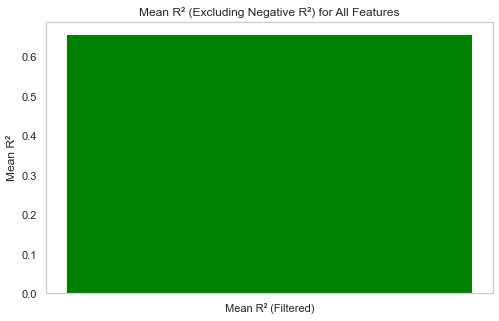

0.6560244078780123


In [116]:
mean_r2_filtered = filtered_data_r2['R²'].mean()

plt.figure(figsize=(8, 5))
plt.bar(['Mean R² (Filtered)'], [mean_r2_filtered], color='green')
plt.title('Mean R² (Excluding Negative R²) for All Features')
plt.ylabel('Mean R²')
plt.grid()
plt.show()
print(mean_r2_filtered)

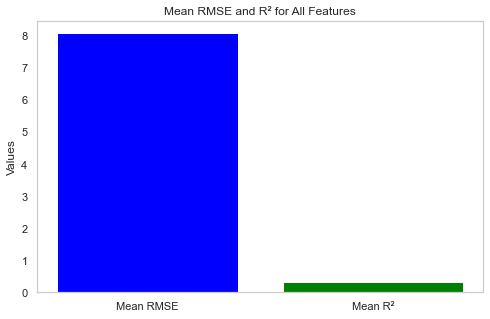

0.33307072631371615


In [110]:
mean_rmse = data['RMSE'].mean()
mean_r2 = data['R²'].mean()

plt.figure(figsize=(8, 5))
plt.bar(['Mean RMSE', 'Mean R²'], [mean_rmse, mean_r2], color=['blue', 'green'])
plt.title('Mean RMSE and R² for All Features')
plt.ylabel('Values')
plt.grid()
plt.show()
print(mean_r2)